In [1]:
from jax.nn import sigmoid
from MCMC.GLM.glm import *
from sklearn.preprocessing import StandardScaler
numpyro.set_host_device_count(4)
plt.style.use("ggplot")

In [2]:
jax.devices()

[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]

# **Regresión lineal**

In [3]:
n = 1000
p = 4
sigma = 2.0
X = 10 + 20 * np.random.rand(n,p)
X = np.hstack((np.ones((n,1)),X))
beta = np.array([2.5, 0.0, -3.5, 0.0, 1.0])
y  = X @ beta + 2.0*np.random.randn(n)

X = jnp.array(X)
y = jnp.array(y)

In [4]:
beta_prior = dist.Normal(0.0, 10.0)
sigma_prior = dist.HalfNormal(0.5)
baye_lr = BayesianLinearRegression(beta_prior=beta_prior, sigma_prior=sigma_prior, burn_in=2000, num_samples=4000, num_chains=4, seed=18081997)

In [5]:
baye_lr.fit(X, y)

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

In [6]:
baye_lr.summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]      2.47      0.43      2.48      1.78      3.20   7699.43      1.00
   beta[1]      0.01      0.01      0.01     -0.00      0.03  12598.25      1.00
   beta[2]     -3.51      0.01     -3.51     -3.53     -3.50  11164.85      1.00
   beta[3]     -0.01      0.01     -0.01     -0.03      0.01  11840.89      1.00
   beta[4]      1.01      0.01      1.01      0.99      1.02  13426.02      1.00
     sigma      1.96      0.04      1.96      1.89      2.03  14192.31      1.00

Number of divergences: 0


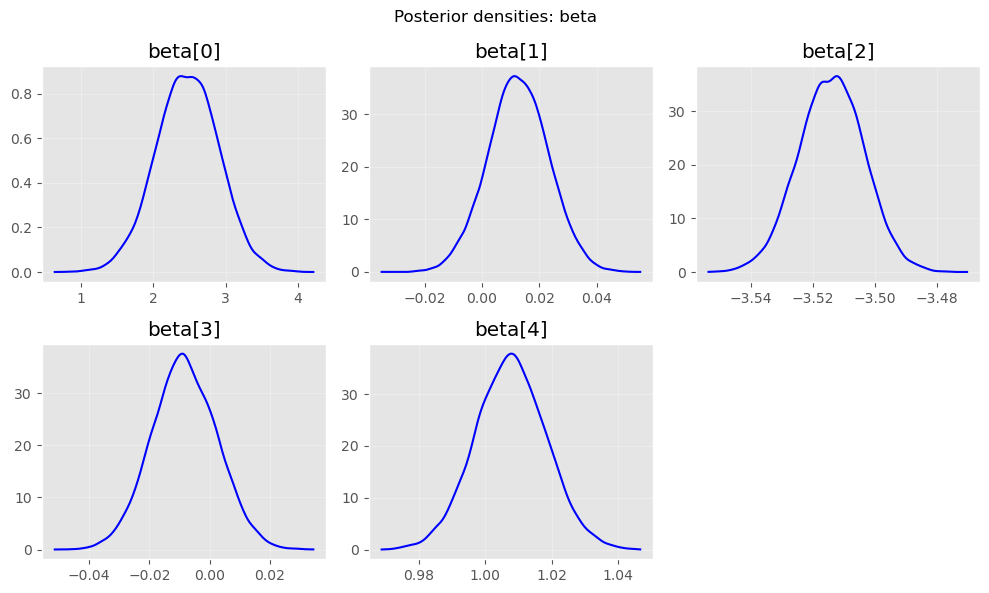

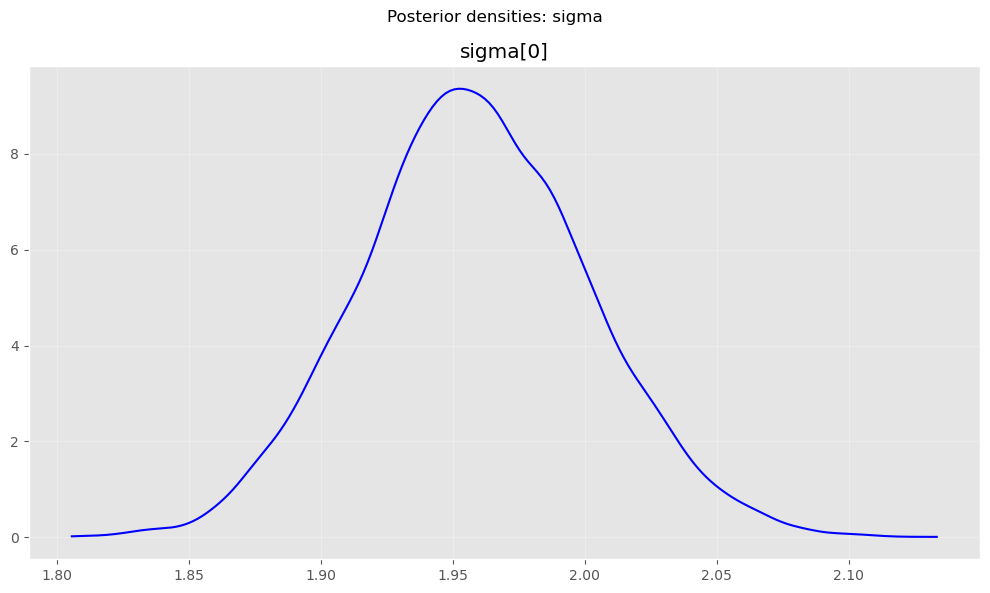

In [7]:
baye_lr.plot_parameter_densities()

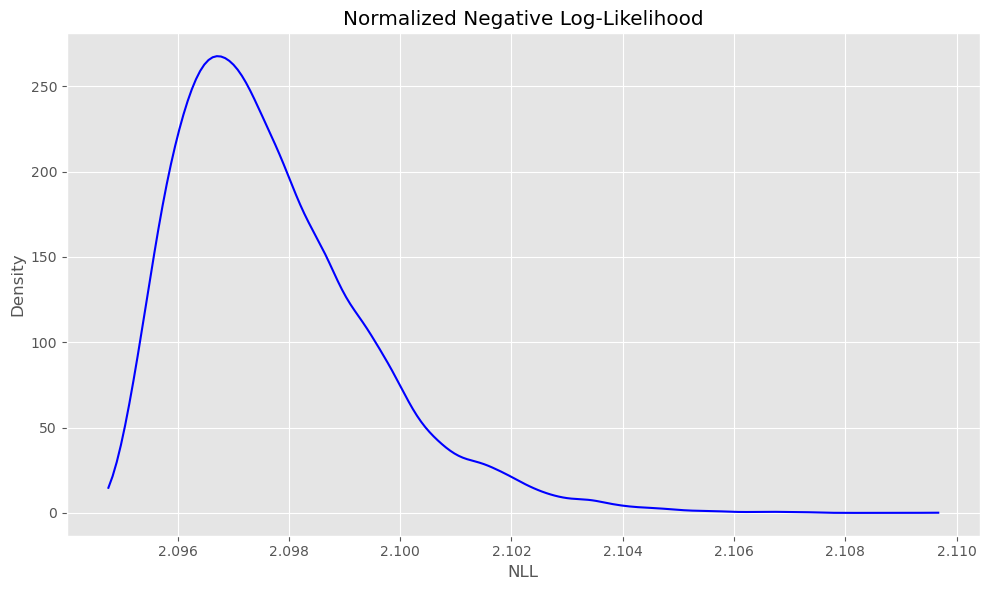

In [8]:
baye_lr.plot_nll_density(X, y)

In [9]:
baye_lr.summary_metrics(X, y)


Model Summary Metrics
           mean           std     median         5%        95%     plugin
NNLL  2.0977259  0.0017430834   2.097385  2.0955303  2.1010764   2.094717
MSE   3.8826468   0.012228791       3.88  3.8677254  3.9058065  3.8633347
MAE   1.5755363    0.00336451  1.5748792  1.5713233  1.5819563  1.5706259


# **Regresión Laplace**

In [10]:
beta_prior = dist.Normal(0.0, 1.0)
b_prior = dist.HalfCauchy(1.0)
baye_lapr = BayesianLaplaceRegression(beta_prior=beta_prior, b_prior=b_prior, burn_in=2000, num_samples=4000, num_chains=4, seed=18081997)

In [11]:
baye_lapr.fit(X, y)

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

In [12]:
baye_lapr.summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         b      1.58      0.05      1.57      1.49      1.66   9660.28      1.00
   beta[0]      1.80      0.42      1.81      1.13      2.51   5883.45      1.00
   beta[1]      0.02      0.01      0.02      0.01      0.04   8127.54      1.00
   beta[2]     -3.51      0.01     -3.51     -3.52     -3.49   9374.26      1.00
   beta[3]     -0.00      0.01     -0.00     -0.02      0.01   8152.73      1.00
   beta[4]      1.01      0.01      1.01      1.00      1.03  10046.79      1.00

Number of divergences: 0


In [13]:
baye_lapr.summary_metrics(X, y, return_data=False)


Laplace Regression Summary Metrics
           mean           std     median         5%        95%     plugin
NNLL  2.1475875  0.0019091652  2.1472666   2.145126  2.1512735  2.1445982
MSE   3.8900414    0.01662073  3.8865232   3.869646  3.9220593   3.873452
MAE    1.574508  0.0027891898  1.5739808  1.5709931  1.5798323  1.5705811


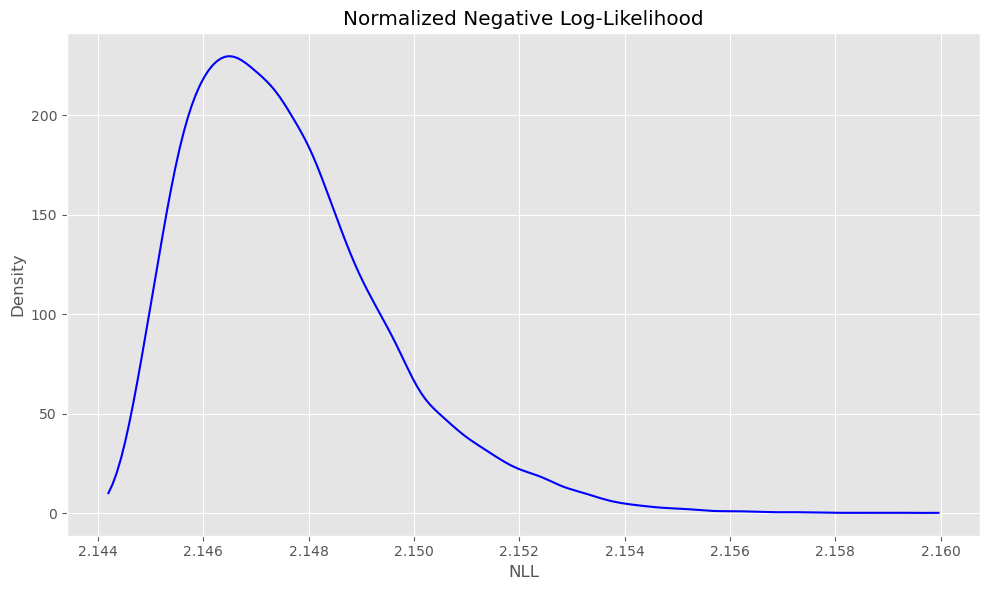

In [14]:
baye_lapr.plot_nll_density(X, y)

# **Laplace vs Normal**

In [15]:
n = 2000
p = 2

# =========================================================
# DATA
# =========================================================

X = np.random.randn(n, p)
X = np.hstack((np.ones((n,1)), X))  # intercepto

beta_true = np.array([1.0, 2.0, -1.5])

# señal
mu = X @ beta_true

# =========================================================
# ruido base (gaussiano)
# =========================================================

noise = 0.5 * np.random.randn(n)

# =========================================================
# OUTLIERS (clave del experimento)
# =========================================================

outlier_idx = np.random.choice(n, size=int(0.05*n), replace=False)

noise[outlier_idx] += np.random.normal(0, 20, size=len(outlier_idx))
# 👆 ruido brutal en pocos puntos

y = mu + noise

# =========================================================
# JAX
# =========================================================

X = jnp.array(X)
y = jnp.array(y)

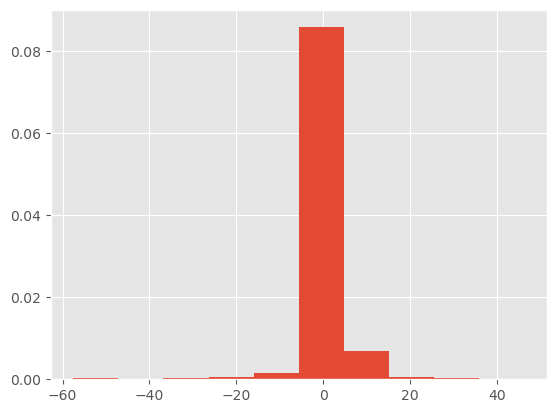

In [16]:
plt.hist(y, density=True)
plt.show()

In [17]:
model_normal = BayesianLinearRegression(num_samples=4000, burn_in=2000, num_chains=4)
model_laplace = BayesianLaplaceRegression(num_samples=4000, burn_in=2000, num_chains=4)

model_normal.fit(X, y)
model_laplace.fit(X, y)

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

In [18]:
df_normal = model_normal.summary_metrics(X, y, return_data=True)
df_laplace = model_laplace.summary_metrics(X, y, return_data=True)


Model Summary Metrics
           mean            std     median         5%        95%     plugin
NNLL  2.9987912  0.00071960216   2.998632  2.9979506    3.00019   2.997805
MSE    23.55074    0.028594477  23.543259  23.519716  23.607832  23.516281
MAE   1.2452713    0.029170996  1.2390888  1.2102575  1.3011764  1.2192839

Laplace Regression Summary Metrics
           mean           std     median         5%        95%     plugin
NNLL  1.8802178  0.0007144425  1.8800541  1.8793831   1.881605  1.8792273
MSE   23.535192  0.0056157922  23.534798   23.52672  23.545002  23.534063
MAE   1.2054118  0.0007463509  1.2052215  1.2045953  1.2068552  1.2045182


# **Regresión Logística**

In [19]:
n = 5000
p = 4
sigma = 2.0
X = 10 * np.random.rand(n,p)
X = np.hstack((np.ones((n,1)),X))
beta = np.array([5.5, 2.3, -1.5, 0.0, 0.0])
probs = sigmoid(X @ beta)
key = random.PRNGKey(18081997)
y = dist.Bernoulli(probs).sample(key)
X = jnp.array(X)
y = jnp.array(y)

In [20]:
beta_prior = dist.Normal(0, 10.0)
log_reg = BayesianLogisticRegression(beta_prior=beta_prior, num_samples=5000, burn_in=2000, num_chains=4,seed=145)
log_reg.fit(X, y)

  0%|          | 0/7000 [00:00<?, ?it/s]

  0%|          | 0/7000 [00:00<?, ?it/s]

  0%|          | 0/7000 [00:00<?, ?it/s]

  0%|          | 0/7000 [00:00<?, ?it/s]

In [21]:
log_reg.summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]      5.67      0.41      5.66      4.99      6.32   8456.95      1.00
   beta[1]      2.41      0.12      2.41      2.20      2.60   8527.77      1.00
   beta[2]     -1.56      0.08     -1.56     -1.69     -1.44   7703.12      1.00
   beta[3]      0.01      0.03      0.01     -0.04      0.06  11907.55      1.00
   beta[4]      0.00      0.03      0.01     -0.05      0.05  12386.60      1.00

Number of divergences: 0


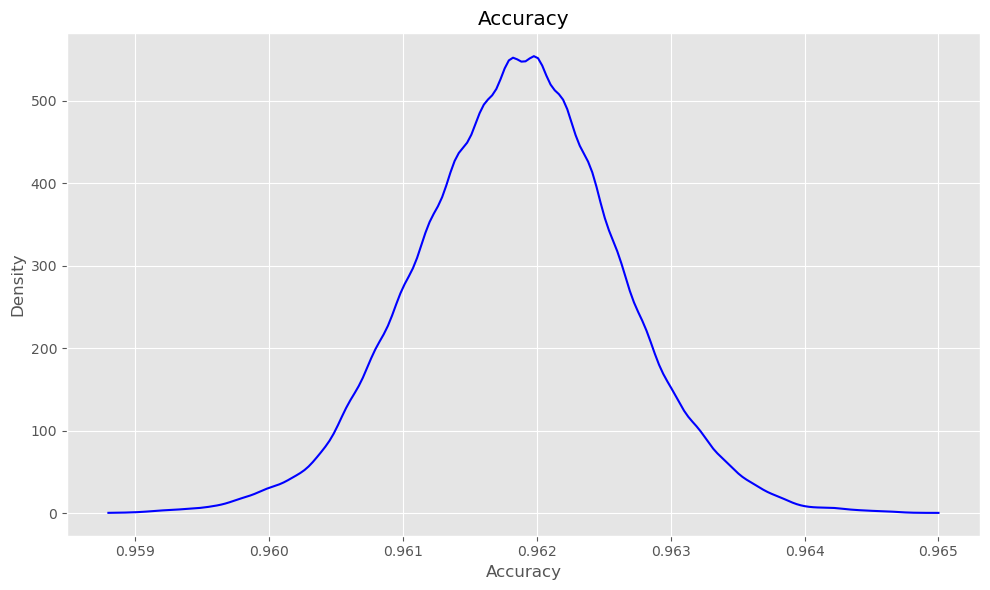

In [22]:
log_reg.plot_accuracy_density(X, y)

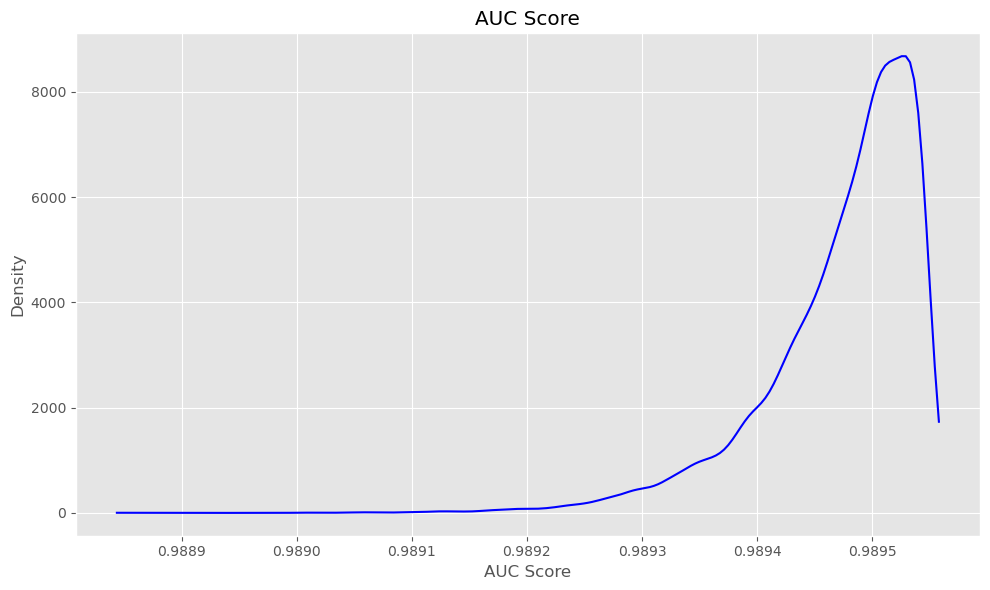

In [23]:
log_reg.plot_auc_density(X, y)

In [24]:
log_reg.summary_metrics(X, y)

,mean,std,median,5%,95%,plugin
NNLL,0.08948425,0.00031455667,0.089420214,0.089104176,0.09008242,0.08898884
AUC,0.9894729,6.684096e-05,0.98949116,0.98933953,0.98954344,0.989541
ACC,0.96185076,0.00075377367,0.9618,0.96059996,0.963,0.9612


# **Regresión Poisson y Binomial Negativa**

In [25]:
n = 5000
p = 4
sigma = 2.0
X = 10 * np.random.rand(n,p)
X = np.hstack((np.ones((n,1)),X))
beta = np.array([0.5, -0.1, 0.5, 0.0, 0.03])
rates = jnp.exp(X @ beta)
y = dist.Poisson(rates).sample(random.PRNGKey(0))
X = jnp.array(X)
y = jnp.array(y)

In [26]:
beta_prior = dist.Normal(0, 10.0)
poi_model = BayesianPoissonRegression(num_samples=5000, burn_in=3000, num_chains=4)
poi_model.fit(X, y)

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

In [27]:
poi_model.summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]      0.48      0.01      0.48      0.46      0.50   5424.47      1.00
   beta[1]     -0.10      0.00     -0.10     -0.10     -0.10  14412.77      1.00
   beta[2]      0.50      0.00      0.50      0.50      0.50   6586.89      1.00
   beta[3]      0.00      0.00      0.00     -0.00      0.00  15349.34      1.00
   beta[4]      0.03      0.00      0.03      0.03      0.03  14255.74      1.00

Number of divergences: 0


In [28]:
poi_model.summary_metrics(X, y)


Summary Normalized Negative Log-Likelihood
------------------------------------------
beta_hat NLL: 2.7387

mean      : 2.7392
std       : 0.0003
median    : 2.7392
5%        : 2.7388
95%       : 2.7398


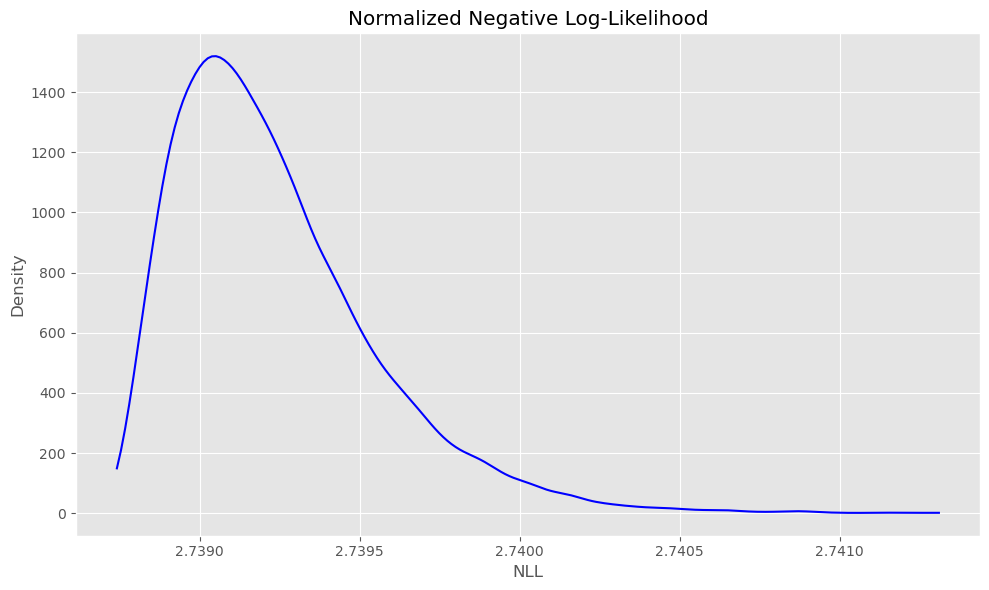

In [29]:
poi_model.plot_nll_density(X, y)

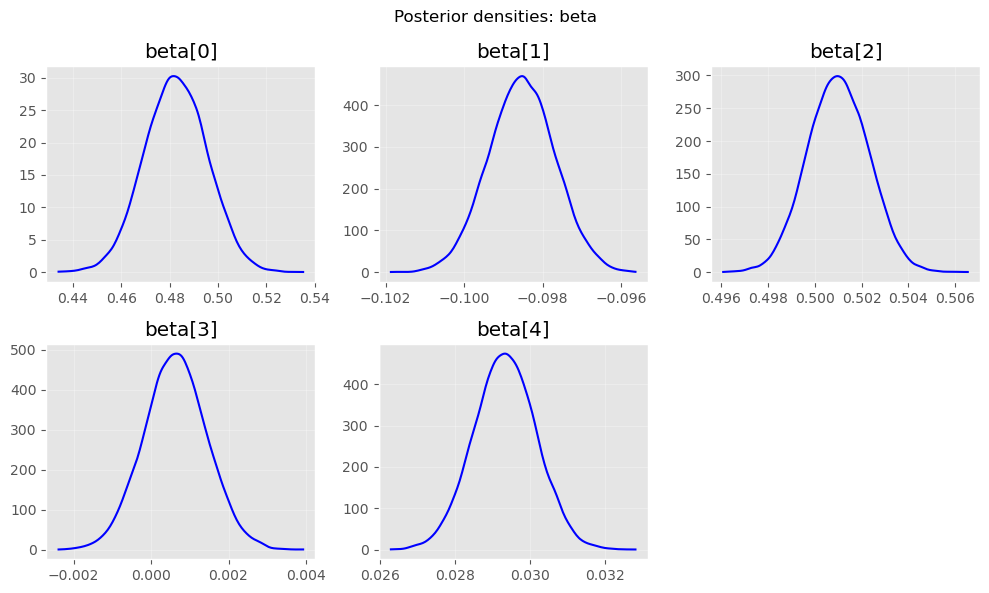

In [30]:
poi_model.plot_parameter_densities()

In [31]:
n = 5000
p = 4
X = 10 * np.random.rand(n,p)
X = np.hstack((np.ones((n,1)),X))
beta = np.array([0.5, -0.1, 0.5, 0.0, 0.03])
rates = jnp.exp(X @ beta)
alpha = 0.5
y = dist.NegativeBinomial2(rates, alpha).sample(random.PRNGKey(1808))
X = jnp.array(X)
y = jnp.array(y)

In [32]:
bin_neg_model = BayesianNegBinomRegression(num_samples=5000, burn_in=3000, num_chains=4)
bin_neg_model.fit(X, y)

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

In [33]:
bin_neg_model.summary()



                mean       std    median      5.0%     95.0%     n_eff     r_hat
     alpha      0.50      0.01      0.50      0.48      0.52  17544.55      1.00
   beta[0]      0.42      0.08      0.42      0.29      0.54   9597.04      1.00
   beta[1]     -0.09      0.01     -0.09     -0.10     -0.08  14965.03      1.00
   beta[2]      0.51      0.01      0.51      0.49      0.52  13614.53      1.00
   beta[3]     -0.00      0.01     -0.00     -0.02      0.01  14799.59      1.00
   beta[4]      0.03      0.01      0.03      0.02      0.05  15780.66      1.00

Number of divergences: 0


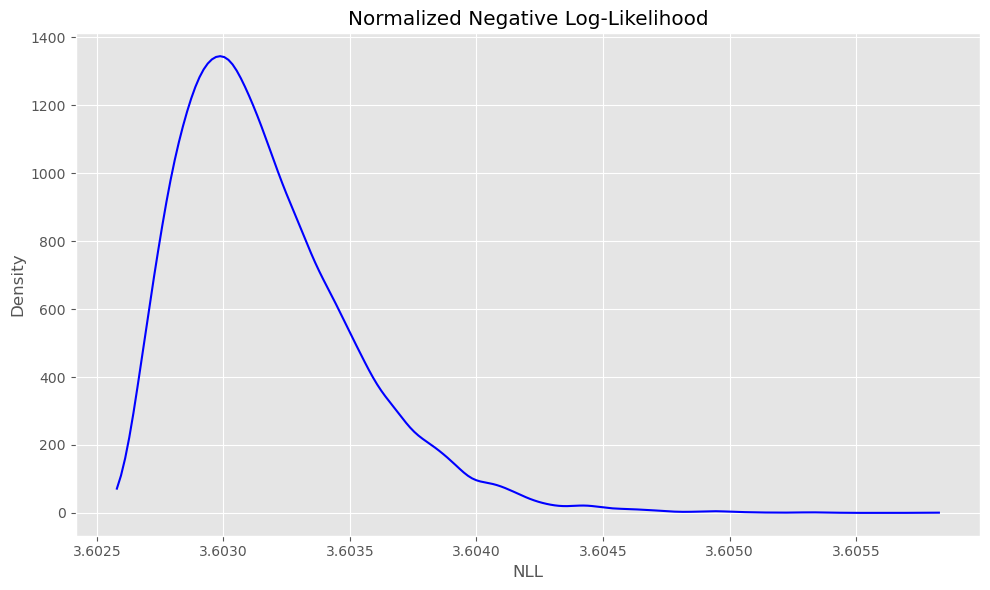

In [34]:
bin_neg_model.plot_nll_density(X, y)

In [35]:
bin_neg_model.summary_metrics(X, y)


Summary Normalized Negative Log-Likelihood
------------------------------------------
beta_hat NLL: 3.6026

mean      : 3.6032
std       : 0.0003
median    : 3.6031
5%        : 3.6027
95%       : 3.6038


In [36]:
poisson_model = BayesianPoissonRegression(num_samples=5000, burn_in=3000, num_chains=4)
poisson_model.fit(X, y)

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

In [37]:
poisson_model.summary_metrics(X, y)


Summary Normalized Negative Log-Likelihood
------------------------------------------
beta_hat NLL: 28.5222

mean      : 28.5227
std       : 0.0003
median    : 28.5226
5%        : 28.5223
95%       : 28.5233


In [38]:
import statsmodels.api as sm

In [39]:
data = sm.datasets.get_rdataset("NMES1988", "AER").data
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4406 entries, 0 to 4405
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   visits     4406 non-null   int64  
 1   nvisits    4406 non-null   int64  
 2   ovisits    4406 non-null   int64  
 3   novisits   4406 non-null   int64  
 4   emergency  4406 non-null   int64  
 5   hospital   4406 non-null   int64  
 6   health     4406 non-null   object 
 7   chronic    4406 non-null   int64  
 8   adl        4406 non-null   object 
 9   region     4406 non-null   object 
 10  age        4406 non-null   float64
 11  afam       4406 non-null   object 
 12  gender     4406 non-null   object 
 13  married    4406 non-null   object 
 14  school     4406 non-null   int64  
 15  income     4406 non-null   float64
 16  employed   4406 non-null   object 
 17  insurance  4406 non-null   object 
 18  medicaid   4406 non-null   object 
dtypes: float64(2), int64(8), object(9)
memory usage:

In [40]:
data

,visits,nvisits,ovisits,novisits,emergency,hospital,health,chronic,adl,region,age,afam,gender,married,school,income,employed,insurance,medicaid
0,5,0,0,0,0,1,average,2,normal,other,6.9,yes,male,yes,6,2.881000,yes,yes,no
1,1,0,2,0,2,0,average,2,normal,other,7.4,no,female,yes,10,2.747800,no,yes,no
2,13,0,0,0,3,3,poor,4,limited,other,6.6,yes,female,no,10,0.653200,no,no,yes
3,16,0,5,0,1,1,poor,2,limited,other,7.6,no,male,yes,3,0.658800,no,yes,no
4,3,0,0,0,0,0,average,2,limited,other,7.9,no,female,yes,6,0.658800,no,yes,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4401,11,0,0,0,0,0,average,0,normal,other,8.4,no,female,yes,8,2.249700,no,yes,no
4402,12,0,0,0,0,0,average,2,normal,other,7.8,no,female,no,11,5.813200,no,yes,no
4403,10,0,20,0,1,1,average,5,normal,other,7.3,no,male,yes,12,3.877916,no,yes,no
4404,16,1,0,0,0,0,average,0,normal,other,6.6,no,female,yes,12,3.877916,no,yes,no


In [41]:


target = "visits"

features = [
    "age", "income", "health",
    "school", "adl", "region", "chronic"
]

data_X = data[features]

data_X = pd.get_dummies(data[features], columns=["region", "adl", "health"], drop_first=True, dtype=int)

y = data.loc[data_X.index, target].values



In [42]:
numeric_cols = ["age", "income", "school", "chronic"]

scaler = StandardScaler()
data_X[numeric_cols] = scaler.fit_transform(data_X[numeric_cols])

X = data_X.values

X = np.concatenate(
    (np.ones((X.shape[0], 1)), X),
    axis=1
)

X = jnp.array(X)
y = jnp.array(y)

In [43]:
poi_model = BayesianPoissonRegression(
    method="mcmc",
    burn_in=1000,
    num_samples=2000,
    num_chains=4
)

poi_model.fit(X, y)

poi_model.summary()

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]      1.74      0.02      1.74      1.71      1.77   5118.35      1.00
   beta[1]     -0.03      0.01     -0.03     -0.04     -0.02  10809.70      1.00
   beta[2]     -0.01      0.01     -0.01     -0.02     -0.00  11837.13      1.00
   beta[3]      0.12      0.01      0.12      0.11      0.13  11932.13      1.00
   beta[4]      0.22      0.01      0.22      0.21      0.23  12383.16      1.00
   beta[5]      0.11      0.02      0.11      0.08      0.14   6863.80      1.00
   beta[6]     -0.01      0.02     -0.01     -0.04      0.02   6216.30      1.00
   beta[7]      0.13      0.02      0.13      0.10      0.16   6614.35      1.00
   beta[8]     -0.11      0.02     -0.11     -0.13     -0.08   6852.23      1.00
   beta[9]     -0.38      0.03     -0.38     -0.43     -0.33   9129.44      1.00
  beta[10]      0.27      0.02      0.27      0.24      0.30   8515.42      1.00

Number of divergences: 0


In [44]:
poi_model.summary_metrics(X, y)


Summary Normalized Negative Log-Likelihood
------------------------------------------
beta_hat NLL: 4.1603

mean      : 4.1616
std       : 0.0005
median    : 4.1615
5%        : 4.1608
95%       : 4.1625


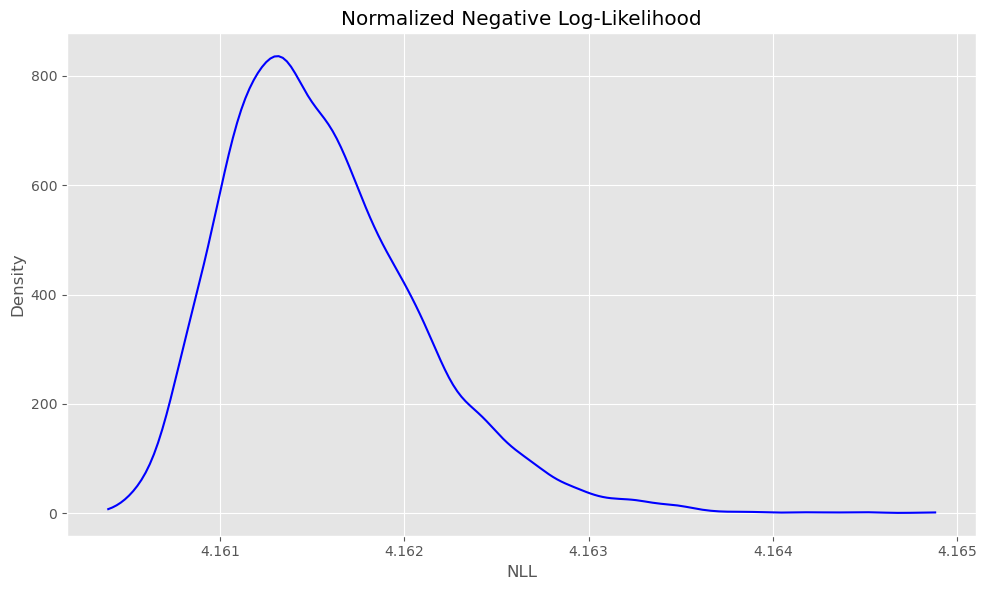

In [45]:
poi_model.plot_nll_density(X, y)

In [46]:
bin_neg_model = BayesianNegBinomRegression(num_samples=2000, burn_in=1000, num_chains=4)
bin_neg_model.fit(X, y)

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

In [47]:
bin_neg_model.summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     alpha      1.15      0.03      1.15      1.10      1.21  10123.94      1.00
   beta[0]      1.74      0.05      1.74      1.66      1.82   4258.94      1.00
   beta[1]     -0.02      0.02     -0.02     -0.05      0.01  10010.38      1.00
   beta[2]     -0.01      0.02     -0.01     -0.03      0.02  11052.19      1.00
   beta[3]      0.13      0.02      0.13      0.10      0.15   9833.79      1.00
   beta[4]      0.26      0.02      0.26      0.23      0.29  10711.14      1.00
   beta[5]      0.11      0.05      0.11      0.03      0.18   5925.40      1.00
   beta[6]     -0.03      0.04     -0.03     -0.10      0.03   5677.90      1.00
   beta[7]      0.12      0.05      0.12      0.04      0.20   6131.21      1.00
   beta[8]     -0.11      0.04     -0.11     -0.18     -0.04   5782.64      1.00
   beta[9]     -0.37      0.06     -0.37     -0.47     -0.27  11470.21      1.00
  beta[10]      0.31      0

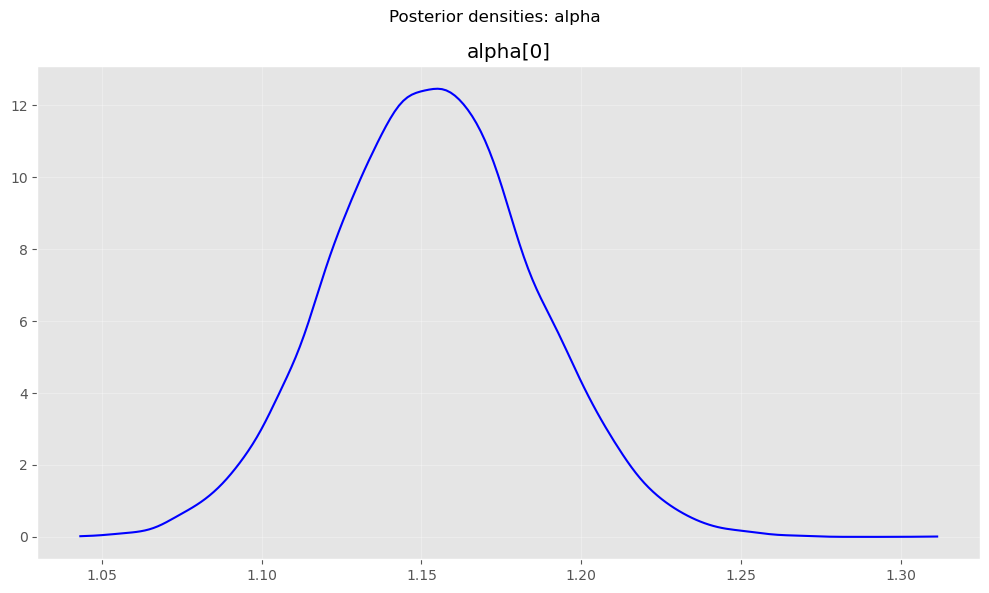

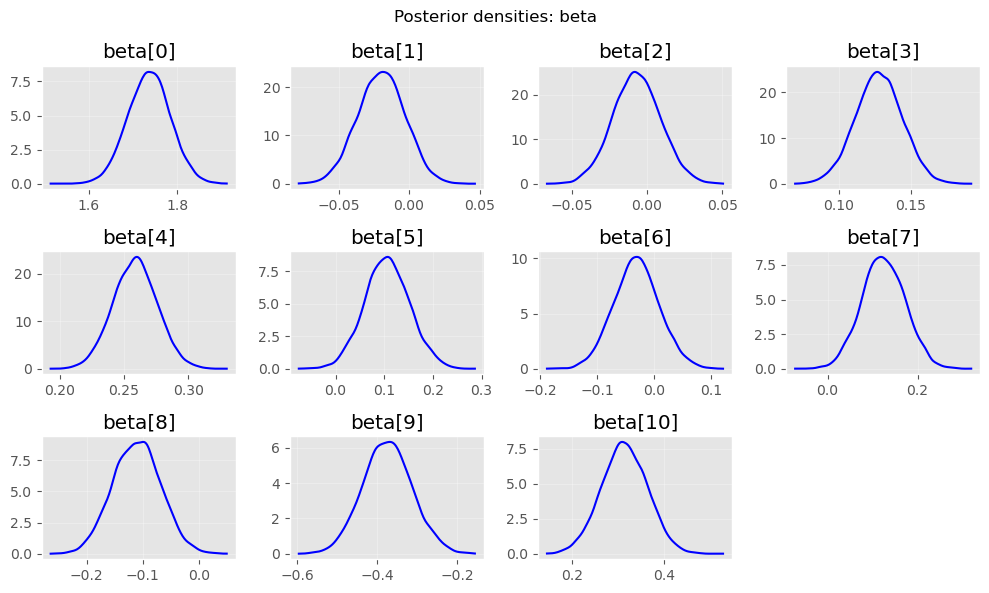

In [48]:
bin_neg_model.plot_parameter_densities()

In [49]:
bin_neg_model.summary_metrics(X, y)


Summary Normalized Negative Log-Likelihood
------------------------------------------
beta_hat NLL: 2.7775

mean      : 2.7789
std       : 0.0006
median    : 2.7788
5%        : 2.7781
95%       : 2.7799


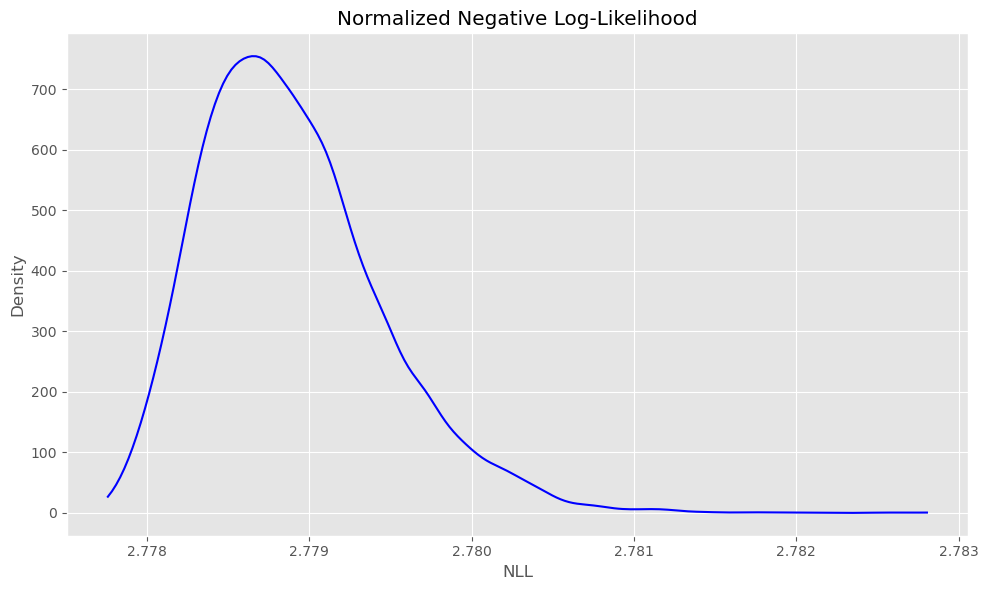

In [50]:
bin_neg_model.plot_nll_density(X, y)

# **Reresión Gamma**

In [51]:
n = 5000
p = 3
alpha = 2.5

X = 10 * np.random.rand(n,p)
X = np.hstack((np.ones((n,1)),X))
beta = np.array([0.8, -1.1, 0.5, 0.0])
mu = jnp.exp(X @ beta)
y = dist.Gamma(alpha, alpha/mu).sample(random.PRNGKey(1808))
X = jnp.array(X)
y = jnp.array(y)

In [52]:
model = BayesianGammaRegression(num_samples=5000, burn_in=3000, num_chains=4)
model.fit(X, y)

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

In [53]:
model.summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     alpha      2.46      0.05      2.46      2.38      2.53  19004.81      1.00
   beta[0]      0.82      0.03      0.82      0.77      0.86  11320.70      1.00
   beta[1]     -1.10      0.00     -1.10     -1.11     -1.10  16879.65      1.00
   beta[2]      0.50      0.00      0.50      0.50      0.51  15771.27      1.00
   beta[3]     -0.00      0.00     -0.00     -0.01      0.00  16441.82      1.00

Number of divergences: 0


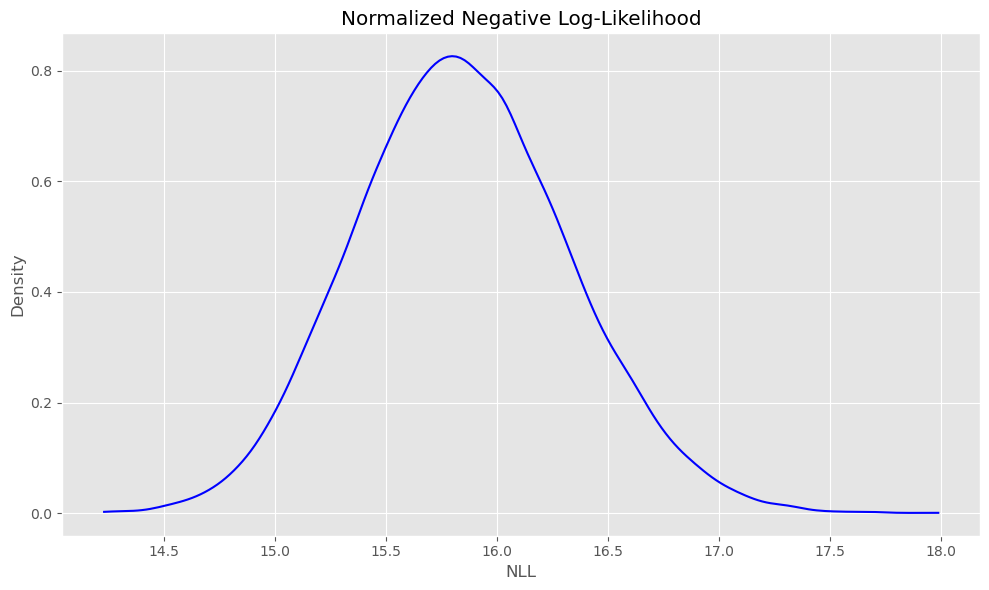

In [54]:
model.plot_nll_density(X, y)

In [55]:
model.summary_metrics(X,y)


Summary Normalized Negative Log-Likelihood
------------------------------------------
beta_hat NLL: 15.8333

mean      : 15.8436
std       : 0.4830
median    : 15.8308
5%        : 15.0737
95%       : 16.6596


In [56]:
n = 5000
p = 3
K = 4   # número de clases

# =========================================================
# DATASET
# =========================================================

X = 10 * np.random.rand(n, p)
X = np.hstack((np.ones((n,1)), X))   # intercepto

# beta: (K, p+1)
beta = np.array([
    [ 0.5, -1.0,  0.3,  0.2],
    [-0.2,  0.8, -0.5,  0.1],
    [ 1.0, -0.3,  0.2, -0.7],
    [-0.5,  0.2,  0.1,  0.5]
])

# =========================================================
# LOGITS
# =========================================================

logits = X @ beta.T

# =========================================================
# PROBABILIDADES (softmax)
# =========================================================

probs = jax.nn.softmax(logits, axis=1)

# =========================================================
# SAMPLE
# =========================================================

key = random.PRNGKey(1808)

y = dist.Categorical(probs=probs).sample(key)

# =========================================================
# CONVERTIR A JAX
# =========================================================

X = jnp.array(X)
y = jnp.array(y)

In [57]:
multinomial_model = BayesianMultinomialRegression(beta_prior=dist.Normal(0,1.0), num_samples=3000, num_chains=4, burn_in=2000, K=4,
                                                  method="svi")
multinomial_model.fit(X, y)

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

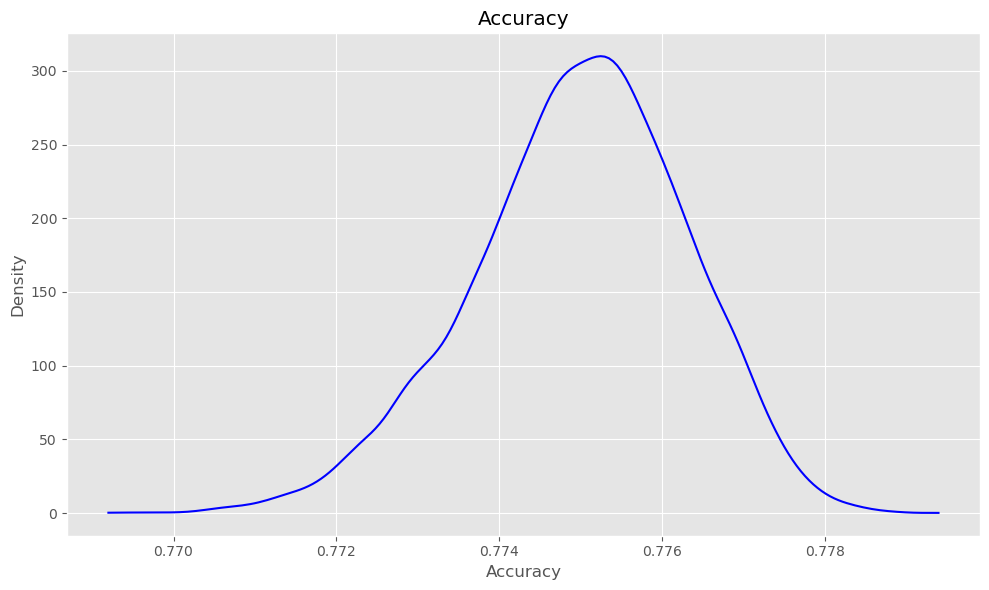

In [58]:
multinomial_model.plot_accuracy_density(X, y)

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", alpha=0.6)
plt.gca().set_aspect('equal')
plt.show()

In [ ]:
def bnn_model(X, y=None, hidden_dim=10, tau=1.0):

    n, d = X.shape

    # -------------------------
    # Priors
    # -------------------------
    W1 = numpyro.sample("W1", dist.Normal(0, tau).expand([d, hidden_dim]))
    b1 = numpyro.sample("b1", dist.Normal(0, tau).expand([hidden_dim]))

    W2 = numpyro.sample("W2", dist.Normal(0, tau).expand([hidden_dim]))
    b2 = numpyro.sample("b2", dist.Normal(0, tau))

    # -------------------------
    # Forward
    # -------------------------
    a = jnp.tanh(jnp.dot(X, W1) + b1)
    logits = jnp.dot(a, W2) + b2

    # -------------------------
    # Likelihood
    # -------------------------
    with numpyro.plate("data", n):

        numpyro.sample("target", dist.Bernoulli(logits=logits), obs=y)

In [ ]:
kernel = NUTS(bnn_model)
mcmc = MCMC(kernel, num_warmup=2000, num_samples=5000, num_chains=3, chain_method="parallel")

rng_key = random.PRNGKey(12756)
mcmc.run(rng_key, X=X, y=y)


In [ ]:
samples = mcmc.get_samples()

In [ ]:
def predict_proba(samples, X):

    W1 = samples["W1"]
    b1 = samples["b1"]
    W2 = samples["W2"]
    b2 = samples["b2"]

    a = jnp.tanh(jnp.matmul(X[None, :, :], W1) + b1[:, None, :])
    logits = jnp.matmul(a, W2[:, :, None]).squeeze(-1) + b2[:, None]

    probs = jax.nn.sigmoid(logits)

    return probs

In [ ]:
probs = predict_proba(samples, X)

mean_probs = probs.mean(axis=0)
y_pred = (mean_probs >= 0.5)

accuracy = (y_pred == y).mean()

In [ ]:
accuracy

In [ ]:
pd.DataFrame(samples['W1'][:, :, 2]).plot()
plt.show()

In [ ]:
pd.DataFrame(samples['b1'][:,8]).plot()
plt.show()

In [ ]:
pd.DataFrame(samples['W1'][:, :, 2]).plot.kde(subplots=True)
plt.show()

In [ ]:
pd.DataFrame(samples['b1'][:, 6]).plot.kde(subplots=True)
plt.show()